# 09 – Vaalikonevertailu 2015, 2019 ja 2023: puheet vs. ehdokkaiden kannat

**Tehtävä:** vastaavatko puolueiden erot puheissa (muistiot 05 ja 06) niiden eroja kannoissa? Kannat lasketaan Ylen vaalikoneista kolmissa eduskuntavaaleissa, ja kunkin vaalin tuloksia verrataan seuraavan kauden puheisiin:

| vaalikone | puhekausi | hallitus |
|---|---|---|
| 2015 | 2015–19 | KESK, KOK, PS (Sipilä) |
| 2019 | 2019–23 | SDP, KESK, VIHR, VAS, RKP (Rinne/Marin) |
| 2023 | 2023–27 | KOK, PS, RKP, KD (Orpo) |

**Kysymykset:**
1. Järjestävätkö vaalikone ja puheet puolueparit samoin? Tämä validoi puhemittarin: mittaako se poliittisia eroja?
2. Seuraako samankaltainen puhe hallitusasemaa vai ideologista läheisyyttä? Kolmen eri hallituksen avulla nämä voidaan erottaa.

Liitteessä on kaksi sivukysymystä: ovatko valitut ehdokkaat lähempänä puolueen linjaa kuin muut, ja ennustaako vaalikoneen sisäinen hajonta puheiden monimuotoisuutta.

**Syötteet:** kolme Ylen vaalikoneaineistoa (`Data/`), `Data/processed/mp_terms.parquet` (muistio 02) sekä `results/party_pairwise.csv`, `party_diversity.csv` (muistio 05) ja `leaveout_party_pairs_term.csv` (muistio 06).
**Tulokset:** `results/vaalikone_*.csv`, kuvat `reports/figures/vaalikone_*.png`.

**Rajoitukset ja etiikka:**
- Vastaajat ovat **ehdokkaita**, joten puolueen ehdokasjoukko on kirjavampi kuin sen eduskuntaryhmä. Siksi vertailu tehdään myös pelkillä valituilla (2015 ja 2019).
- Vaalikone mittaa ilmoitettuja kantoja, puhemalli sitä, mistä ja millä sanoilla puhutaan. Asteikot ovat eri, joten vertaamme **järjestyksiä**.
- **Kysymykset vaihtuvat vaaleista toiseen,** joten tasoja ei verrata vuosien välillä.
- Vuoden 2015 nimiä käytetään vain valittujen tunnistamiseen, eikä tuloksia raportoida henkilöittäin. Vuosien 2019 ja 2023 anonymisoituja ehdokkaita ei yritetä tunnistaa. Arkaluonteisia taustatietoja ei käytetä.

In [1]:
import sys
from itertools import combinations, permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
import config

DATA = "../Data/"
TULOKSET = "../results/"
KUVAT = "../reports/figures/"
PUOLUEET = config.MAIN_PARTIES
VARIT = config.PARTY_COLORS
VUODET = [2015, 2019, 2023]
KAUSI = {2015: "2015-2019", 2019: "2019-2023", 2023: "2023-2027"}
MIN_VASTATTU = 0.8        # ehdokkaan pitää vastata vähintään 80 %:iin väitteistä
pd.set_option("display.max_colwidth", 110)

## 1. Aineistojen lukeminen

Jokaiselle vuodelle on oma lukufunktio, ja kaikki palauttavat saman rakenteen: `party`, `vaalipiiri`, `valittu` ja yksi sarake per valtakunnallinen väite. Vastaukset ovat 1 = täysin eri mieltä, 2 = jokseenkin eri mieltä, 4 = jokseenkin samaa mieltä ja 5 = täysin samaa mieltä; neutraalia vaihtoehtoa ei ole.

| | 2015 | 2019 | 2023 |
|---|---|---|---|
| valtakunnalliset väitteet | 26 (+ 6 kyllä/ei, ei käytetä) | 29 | 47 |
| valintatieto | päätellään nimistä (osio 2) | aineistossa | ei |

Vaalipiirikohtaiset väitteet ja Ahvenanmaa jätetään pois. Vuoden 2015 tiedostossa oli yksi virheellinen merkki, joka korjattiin alkuperäiseen tiedostoon (README, *Changes to raw data*).

In [2]:
PUOLUEEN_NIMI = {
    # 2015
    "Suomen Keskusta": "KESK", "Suomen Sosialidemokraattinen Puolue": "SDP", "Vasemmistoliitto": "VAS",
    "Kansallinen Kokoomus": "KOK", "Perussuomalaiset": "PS", "Vihreä liitto": "VIHR",
    "Suomen Kristillisdemokraatit (KD)": "KD", "Suomen ruotsalainen kansanpuolue": "RKP",
    # 2019 ja 2023
    "SDP": "SDP", "Sosialidemokraatit": "SDP", "Keskusta": "KESK", "Vihreät": "VIHR", "Kokoomus": "KOK",
    "Kristillisdemokraatit": "KD", "RKP": "RKP",
}
ASTEIKKO_2015 = {"täysin eri mieltä": 1, "jokseenkin eri mieltä": 2,
                 "jokseenkin samaa mieltä": 4, "täysin samaa mieltä": 5}


def lue_2015():
    d = pd.read_csv(DATA + "avoin_data_eduskuntavaalit_2015.csv", sep=";", dtype=str, encoding="utf-8")

    # valtakunnalliset väitteet: tunnukset 127-152, 201 ja 244-248; kommenttisarakkeet pois
    vaitteet = []
    for sarake in d.columns:
        tunnus = sarake.split("|")[0]
        if "|" in sarake and "kommentti" not in sarake and tunnus.isdigit():
            if 127 <= int(tunnus) <= 152 or int(tunnus) == 201 or 244 <= int(tunnus) <= 248:
                vaitteet.append(sarake)
    viisiportaiset = [s for s in vaitteet if d[s].isin(ASTEIKKO_2015).any()]

    tulos = pd.DataFrame({
        "party": d["puolue"].map(PUOLUEEN_NIMI),
        "vaalipiiri": d["vaalipiiri"],
        "etunimi": d["etunimi"].str.strip(),
        "sukunimi": d["sukunimi"].str.strip(),
    })
    for sarake in viisiportaiset:
        tulos[sarake.split("|", 1)[1].strip()] = d[sarake].map(ASTEIKKO_2015)
    kysymykset = [s.split("|", 1)[1].strip() for s in viisiportaiset]
    print("2015: kyllä/ei-väitteitä pois", len(vaitteet) - len(viisiportaiset))
    return tulos, kysymykset


def lue_2019():
    d = pd.read_csv(DATA + "Avoin_data_eduskuntavaalit_2019_valintatiedot.csv", dtype=str)
    valintatieto = d.columns[2]
    # valtakunnalliset väitteet ovat sarakkeet 3-31; seuraavat 29 saraketta ovat perusteluja
    kysymykset = list(d.columns[3:32])
    tulos = pd.DataFrame({
        "party": d["puolue"].map(PUOLUEEN_NIMI),
        "vaalipiiri": d["vaalipiiri"],
        "valittu": d[valintatieto] == "1",
    })
    for sarake in kysymykset:
        tulos[sarake.strip()] = pd.to_numeric(d[sarake], errors="coerce")   # "-" -> puuttuu
    return tulos, [s.strip() for s in kysymykset]


def lue_2023():
    d = pd.read_csv(DATA + "Eduskuntavaalit 2023 vastausdata - Kaikki vaalipiirit - anonyymi.csv")
    kysymykset = list(d.columns[2:])
    tulos = pd.DataFrame({"party": d["puolue"].map(PUOLUEEN_NIMI), "vaalipiiri": d["vaalipiiri"]})
    for sarake in kysymykset:
        tulos[sarake.strip()] = d[sarake]
    return tulos, [s.strip() for s in kysymykset]


ehdokkaat = {}
kysymykset = {}
for vuosi, lue in [(2015, lue_2015), (2019, lue_2019), (2023, lue_2023)]:
    d, k = lue()
    ehdokkaat[vuosi] = d
    kysymykset[vuosi] = k
    print(vuosi, "ehdokkaita", len(d), "väitteitä", len(k))

2015: kyllä/ei-väitteitä pois 6
2015 ehdokkaita 1998 väitteitä 26
2019 ehdokkaita 2437 väitteitä 29


2023 ehdokkaita 2116 väitteitä 47


### Tarkistukset

Vastausten jakauma (vain arvot 1, 2, 4, 5 ja puuttuva), puuttuvien osuus ja asteikon suunta. Suunta tarkistetaan väitteellä, jonka vastaus on ilmeinen: esim. maahanmuuton rajoittamista koskevan väitteen keskiarvo on korkein perussuomalaisilla.

In [3]:
for vuosi in VUODET:
    arvot = pd.Series(ehdokkaat[vuosi][kysymykset[vuosi]].values.ravel())
    print(vuosi, "vastaukset:", arvot.value_counts(dropna=False).sort_index().to_dict())

suunta = {2015: "Maahanmuuttoa Suomeen on rajoitettava terrorismin uhan vuoksi.",
          2019: "Maahanmuuttajien määrän kasvu on lisännyt turvattomuutta Suomessa.",
          2023: "Suomen pitää vastaanottaa nykyistä vähemmän kiintiöpakolaisia pakolaisleireiltä."}
for vuosi, vaite in suunta.items():
    d = ehdokkaat[vuosi]
    print(vuosi, vaite)
    print("   ", d[d["party"].isin(PUOLUEET)].groupby("party")[vaite].mean().reindex(PUOLUEET).round(1).to_dict())

2015 vastaukset: {1.0: 10132, 2.0: 14239, 4.0: 14222, 5.0: 8189, nan: 5166}
2019 vastaukset: {1.0: 13796, 2.0: 16164, 4.0: 18408, 5.0: 16444, nan: 5861}
2023 vastaukset: {1.0: 20562, 2.0: 23867, 4.0: 28276, 5.0: 26746, nan: 1}
2015 Maahanmuuttoa Suomeen on rajoitettava terrorismin uhan vuoksi.
    {'VAS': 1.4, 'SDP': 1.9, 'VIHR': 1.4, 'KESK': 2.4, 'RKP': 1.3, 'KD': 2.8, 'KOK': 2.3, 'PS': 4.3}
2019 Maahanmuuttajien määrän kasvu on lisännyt turvattomuutta Suomessa.
    {'VAS': 2.1, 'SDP': 3.0, 'VIHR': 2.2, 'KESK': 3.9, 'RKP': 2.4, 'KD': 4.2, 'KOK': 4.0, 'PS': 5.0}
2023 Suomen pitää vastaanottaa nykyistä vähemmän kiintiöpakolaisia pakolaisleireiltä.
    {'VAS': 1.6, 'SDP': 1.8, 'VIHR': 1.4, 'KESK': 2.7, 'RKP': 1.6, 'KD': 2.5, 'KOK': 2.7, 'PS': 4.7}


## 2. Valitut ehdokkaat

- **2019:** valintatieto on aineistossa (1 = valittu; varalle jääneitä ei lasketa).
- **2015:** valituiksi merkitään ehdokkaat, jotka puhuivat eduskunnassa kaudella 2015–19, myös kesken kauden nousseet varajäsenet. Yhdistäminen tehdään nimellä: ensin koko nimi, sitten sukunimi ja jokin etunimistä samasta puolueesta. Nimenmuutokset annetaan käsin (`AIEMMAT_NIMET`). Siniset olivat vuonna 2015 PS:n ehdokkaita.
- **2023:** valintatietoa ei ole, eikä anonymisoitua aineistoa yhdistetä.

In [4]:
# Nimenmuutokset: puheaineistossa on nykyinen nimi, vaalikoneessa vuoden 2015 nimi
AIEMMAT_NIMET = {
    "Elina Valtonen": "Elina Lepomäki",
    "Riitta Kaarisalo": "Riitta Mäkinen",
}

edustajat = pd.read_parquet(DATA + "processed/mp_terms.parquet")
edustajat = edustajat[edustajat["term"] == "2015-2019"].copy()
edustajat["party"] = edustajat["party"].replace({"SIN": "PS"})
edustajat = edustajat.drop_duplicates(["person_id", "party"])

d15 = ehdokkaat[2015]
d15["nimi"] = d15["etunimi"] + " " + d15["sukunimi"]
d15["valittu"] = False

loytyi = set()
ei_loytynyt = []
for henkilo, nimi, puolue in zip(edustajat["person_id"], edustajat["mp_name"], edustajat["party"]):
    if nimi in AIEMMAT_NIMET:
        nimi = AIEMMAT_NIMET[nimi]
    osumat = d15[(d15["nimi"] == nimi) & (d15["party"] == puolue)]
    if len(osumat) == 0:
        # sukunimi + ensimmäinen etunimi (toiset nimet ja nimikirjaimet pois)
        osat = nimi.split()
        samat = (d15["sukunimi"] == osat[-1]) & (d15["party"] == puolue)
        etunimi_mukana = d15["etunimi"].str.split().apply(lambda nimet: osat[0] in nimet)
        osumat = d15[samat & etunimi_mukana]
    if len(osumat) == 1:
        d15.loc[osumat.index, "valittu"] = True
        loytyi.add(henkilo)
    else:
        ei_loytynyt.append((henkilo, nimi + " (" + puolue + ")"))

# puoluetta vaihtaneet ovat taulussa kahdesti; riittää, että toinen rivi löytyi
ei_loytynyt = [nimi for henkilo, nimi in ei_loytynyt if henkilo not in loytyi]

print("Kauden 2015-19 edustajia (8 puoluetta):", edustajat.loc[edustajat["party"].isin(PUOLUEET), "person_id"].nunique())
print("Yhdistetty vaalikoneeseen:", len(loytyi))
print("Ei löytynyt vaalikoneesta (ei ehdokkaana tai ei vastannut):", ei_loytynyt)
ehdokkaat[2015] = d15

Kauden 2015-19 edustajia (8 puoluetta): 210
Yhdistetty vaalikoneeseen: 210
Ei löytynyt vaalikoneesta (ei ehdokkaana tai ei vastannut): []


### Rajaukset

Kaikille vuosille: 8 puoluetta, ei Ahvenanmaan vaalipiiriä, ja ehdokkaan on pitänyt vastata vähintään 80 %:iin väitteistä. Vuonna 2015 osa ehdokkaista ei vastannut lainkaan.

In [5]:
for vuosi in VUODET:
    d = ehdokkaat[vuosi]
    vastattu = d[kysymykset[vuosi]].notna().mean(axis=1)
    mukana = d["party"].isin(PUOLUEET)
    mukana = mukana & ~d["vaalipiiri"].str.contains("Ahvenanmaa")
    mukana = mukana & (vastattu >= MIN_VASTATTU)
    ehdokkaat[vuosi] = d[mukana].reset_index(drop=True)
    if vuosi == 2015:
        print("2015: valituiksi merkityistä jäi pois alle 80 %:iin vastanneita:", int(d.loc[~mukana, "valittu"].sum()))
    print(vuosi, "mukana", mukana.sum(), "ehdokasta;",
          ehdokkaat[vuosi]["party"].value_counts().reindex(PUOLUEET).to_dict())

2015: valituiksi merkityistä jäi pois alle 80 %:iin vastanneita: 7
2015 mukana 1453 ehdokasta; {'VAS': 195, 'SDP': 207, 'VIHR': 195, 'KESK': 200, 'RKP': 83, 'KD': 174, 'KOK': 205, 'PS': 194}
2019 mukana 1522 ehdokasta; {'VAS': 205, 'SDP': 208, 'VIHR': 211, 'KESK': 208, 'RKP': 97, 'KD': 176, 'KOK': 208, 'PS': 209}
2023 mukana 1504 ehdokasta; {'VAS': 211, 'SDP': 208, 'VIHR': 211, 'KESK': 193, 'RKP': 105, 'KD': 161, 'KOK': 208, 'PS': 207}


In [6]:
for vuosi in [2015, 2019]:
    d = ehdokkaat[vuosi]
    print(vuosi, "valittuja puolueittain:", d[d["valittu"]]["party"].value_counts().reindex(PUOLUEET).to_dict())

2015 valittuja puolueittain: {'VAS': 12, 'SDP': 35, 'VIHR': 15, 'KESK': 49, 'RKP': 10, 'KD': 5, 'KOK': 40, 'PS': 37}
2019 valittuja puolueittain: {'VAS': 16, 'SDP': 38, 'VIHR': 20, 'KESK': 31, 'RKP': 9, 'KD': 5, 'KOK': 38, 'PS': 38}


## 3. Puolueiden kannat

Puolueen **kanta** on sen ehdokkaiden vastausten keskiarvo kussakin väitteessä. Taulukossa ovat kuvailun vuoksi väitteet, jotka erottelevat puolueita eniten: η² (*eta squared*) on se osuus vastausten vaihtelusta, jonka puolue selittää. Joka vuonna kärjessä ovat talous (menojen leikkaus vs. verot, sosiaaliturva), ilmasto ja metsät sekä maahanmuutto.

In [7]:
def eta2(d, kysymys):
    """Puolueen selittämä osuus väitteen vastausten vaihtelusta."""
    arvot = d[["party", kysymys]].dropna()
    ka = arvot[kysymys].mean()
    puolueen_ka = arvot.groupby("party")[kysymys].transform("mean")
    return ((puolueen_ka - ka) ** 2).sum() / ((arvot[kysymys] - ka) ** 2).sum()


kannat = {}
erottelu = []
for vuosi in VUODET:
    d = ehdokkaat[vuosi]
    kannat[vuosi] = d.groupby("party")[kysymykset[vuosi]].mean().reindex(PUOLUEET)
    kannat[vuosi].T.to_csv(TULOKSET + f"vaalikone_{vuosi}_party_means.csv")
    for k in kysymykset[vuosi]:
        erottelu.append({"vuosi": vuosi, "kysymys": k, "eta2": eta2(d, k)})
erottelu = pd.DataFrame(erottelu)
erottelu.to_csv(TULOKSET + "vaalikone_question_eta2.csv", index=False)

for vuosi in VUODET:
    osa = erottelu[erottelu["vuosi"] == vuosi].sort_values("eta2", ascending=False)
    print(vuosi, "- eniten puolueita erottelevat väitteet:")
    display(osa.head(6)[["kysymys", "eta2"]].round(2))

2015 - eniten puolueita erottelevat väitteet:


,kysymys,eta2
10,Nato-jäsenyys vahvistaisi Suomen turvallisuuspoliittista asemaa.,0.53
12,Maahanmuuttoa Suomeen on rajoitettava terrorismin uhan vuoksi.,0.50
5,Euron ulkopuolella Suomi pärjäisi paremmin.,0.48
17,Terveys- ja sosiaalipalvelut on tuotettava ensijaisesti julkisina palveluina.,0.48
23,Suomen pitää ottaa suurempi vastuu EU:n alueelle tulevista turvapaikanhakijoista.,0.48
7,Valtion ja kuntien taloutta on tasapainotettava ensisijaisesti leikkaamalla menoja.,0.47


2019 - eniten puolueita erottelevat väitteet:


,kysymys,eta2
31,"Sosiaaliturvaa tulee kehittää niin, että osa nykyisistä tuista korvataan kaikille työikäisille maksettaval...",0.58
26,"Suomen pitää olla edelläkävijä ilmastonmuutoksen vastaisessa taistelussa, vaikka se aiheuttaisi suomalaisi...",0.53
29,Metsiä hakataan Suomessa liikaa.,0.53
30,"Kun valtion menoja ja tuloja tasapainotetaan, se on tehtävä mieluummin menoja karsimalla kuin veroja kiris...",0.51
32,Euron ulkopuolella Suomi pärjäisi paremmin.,0.51
44,Maahanmuuttajien määrän kasvu on lisännyt turvattomuutta Suomessa.,0.50


2023 - eniten puolueita erottelevat väitteet:


,kysymys,eta2
76,"Kun valtion menoja ja tuloja tasapainotetaan, se on tehtävä mieluummin menoja vähentämällä kuin veroja kor...",0.67
57,Suomessa on liian helppo elää yhteiskunnan tukien varassa.,0.62
55,Suomen pitää ottaa käyttöön kolmas virallinen sukupuoli.,0.61
63,Metsähakkuita pitää rajoittaa ilmastopäästöjä poistavien hiilinielujen kasvattamiseksi.,0.61
74,Kehitysyhteistyöhön käytettäviä varoja on leikattava.,0.60
66,"Suomen pitää olla edelläkävijä ilmastonmuutoksen hidastamisessa, vaikka se aiheuttaisi suomalaisille kusta...",0.59


## 4. Puolueiden väliset etäisyydet

Kahden puolueen **etäisyys** on kantojen keskineliöero väitteiden yli (*root mean square difference*), asteikkopisteinä. Puolueen kanta on otoskeskiarvo, joten sen satunnaisvaihtelu kasvattaa etäisyyttä (Gentzkow ym.). Korjaus vähentää neliöerosta keskiarvojen varianssit väitekohtaisesti:

$$d^2_{AB} = \frac{1}{K}\sum_k \left[(\bar x_{Ak} - \bar x_{Bk})^2 - \frac{s^2_{Ak}}{n_{Ak}} - \frac{s^2_{Bk}}{n_{Bk}}\right]$$

jossa $n_{Ak}$ on väitteeseen $k$ vastanneiden puolueen A ehdokkaiden määrä. Korjaus on tärkeä, kun etäisyydet lasketaan vain valituista (esim. KD:llä 5 valittua vuonna 2019). Keskiarvon varianssi $s^2/n$: [SfDS 2.6](https://lacerbi.github.io/stats-for-ds-website/chapters/02-expectation.html#sample-mean-and-variance).

In [8]:
def etaisyydet(d, kysymykset_vuosi):
    """Kohinakorjattu RMS-etäisyys puolueiden kantojen välillä (osion 4 kaava)."""
    ryhmat = d.groupby("party")[kysymykset_vuosi]
    ka, var, n = ryhmat.mean().reindex(PUOLUEET), ryhmat.var().reindex(PUOLUEET), ryhmat.count().reindex(PUOLUEET)
    matriisi = pd.DataFrame(0.0, index=PUOLUEET, columns=PUOLUEET)
    for a, b in combinations(PUOLUEET, 2):
        ero2 = (ka.loc[a] - ka.loc[b]) ** 2
        kohina = var.loc[a] / n.loc[a] + var.loc[b] / n.loc[b]
        arvo = np.sqrt(max((ero2 - kohina).mean(), 0))
        matriisi.loc[a, b] = arvo
        matriisi.loc[b, a] = arvo
    return matriisi


vk_etaisyys = {}
rivit = []
for vuosi in VUODET:
    otokset = {"kaikki": ehdokkaat[vuosi]}
    if vuosi in (2015, 2019):
        otokset["valitut"] = ehdokkaat[vuosi][ehdokkaat[vuosi]["valittu"]]
    for otos, d in otokset.items():
        m = etaisyydet(d, kysymykset[vuosi])
        vk_etaisyys[(vuosi, otos)] = m
        for a, b in combinations(PUOLUEET, 2):
            rivit.append({"vuosi": vuosi, "otos": otos, "a": a, "b": b, "etäisyys": m.loc[a, b]})
pd.DataFrame(rivit).to_csv(TULOKSET + "vaalikone_distances.csv", index=False)

for vuosi in VUODET:
    print(vuosi, "(kaikki ehdokkaat)")
    display(vk_etaisyys[(vuosi, "kaikki")].round(2))

2015 (kaikki ehdokkaat)


,VAS,SDP,VIHR,KESK,RKP,KD,KOK,PS
VAS,0.00,0.72,0.72,1.15,1.24,1.29,1.78,1.37
SDP,0.72,0.00,0.79,0.84,0.92,0.89,1.35,1.06
VIHR,0.72,0.79,0.00,0.87,0.76,1.11,1.29,1.31
KESK,1.15,0.84,0.87,0.00,0.74,0.60,0.86,0.71
RKP,1.24,0.92,0.76,0.74,0.00,0.83,0.77,1.24
KD,1.29,0.89,1.11,0.60,0.83,0.00,1.00,0.87
KOK,1.78,1.35,1.29,0.86,0.77,1.00,0.00,1.18
PS,1.37,1.06,1.31,0.71,1.24,0.87,1.18,0.00


2019 (kaikki ehdokkaat)


,VAS,SDP,VIHR,KESK,RKP,KD,KOK,PS
VAS,0.00,0.69,0.48,1.14,1.06,1.45,1.48,1.78
SDP,0.69,0.00,0.90,0.66,0.75,1.02,1.09,1.45
VIHR,0.48,0.90,0.00,1.30,1.04,1.58,1.46,1.98
KESK,1.14,0.66,1.30,0.00,0.73,0.62,0.73,1.01
RKP,1.06,0.75,1.04,0.73,0.00,1.11,0.60,1.39
KD,1.45,1.02,1.58,0.62,1.11,0.00,1.01,1.09
KOK,1.48,1.09,1.46,0.73,0.60,1.01,0.00,1.13
PS,1.78,1.45,1.98,1.01,1.39,1.09,1.13,0.00


2023 (kaikki ehdokkaat)


,VAS,SDP,VIHR,KESK,RKP,KD,KOK,PS
VAS,0.00,0.78,0.80,1.62,1.25,1.61,1.83,2.10
SDP,0.78,0.00,0.81,1.07,0.76,1.10,1.28,1.62
VIHR,0.80,0.81,0.00,1.48,0.86,1.55,1.46,2.08
KESK,1.62,1.07,1.48,0.00,0.82,0.46,0.66,0.97
RKP,1.25,0.76,0.86,0.82,0.00,0.97,0.79,1.56
KD,1.61,1.10,1.55,0.46,0.97,0.00,0.82,0.89
KOK,1.83,1.28,1.46,0.66,0.79,0.82,0.00,1.13
PS,2.10,1.62,2.08,0.97,1.56,0.89,1.13,0.00


## 5. Puheiden erottuvuus ja kartat rinnakkain

Puheiden erottuvuusmatriisi luetaan muistion 05 tuloksista kullekin kaudelle ja leave-out-mittari muistion 06 tuloksista. Kartat tehdään klassisella MDS:llä; vaalikonekartta kierretään puhekartan asentoon (Procrustes), mikä ei muuta etäisyyksiä.

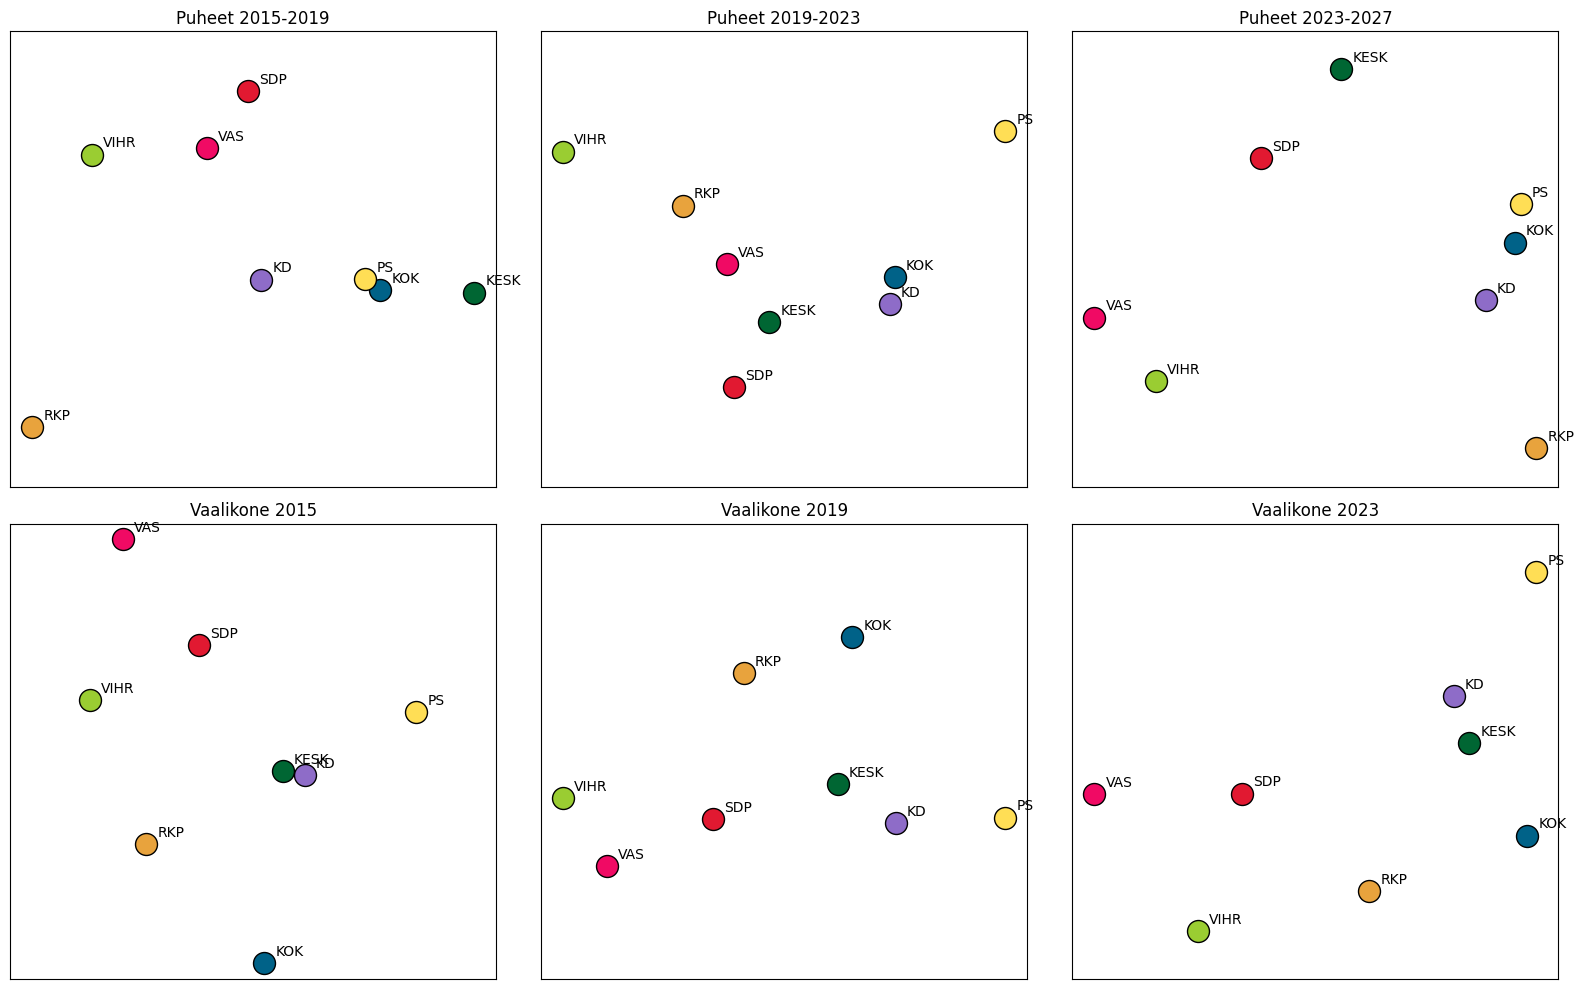

In [9]:
parit = pd.read_csv(TULOKSET + "party_pairwise.csv")
parit = parit[parit["series"] == "real"]
leaveout = pd.read_csv(TULOKSET + "leaveout_party_pairs_term.csv")

def parimatriisi(taulu, arvosarake):
    """Symmetrinen puolueet × puolueet -taulukko pareittaisista arvoista (sarakkeet a ja b)."""
    m = taulu.groupby(["a", "b"])[arvosarake].mean().unstack().reindex(index=PUOLUEET, columns=PUOLUEET)
    return (m.fillna(0) + m.T.fillna(0)).rename_axis(index=None, columns=None)


puhe = {vuosi: parimatriisi(parit[parit["term"] == KAUSI[vuosi]], "d") for vuosi in VUODET}
pi = {vuosi: parimatriisi(leaveout[leaveout["term"] == KAUSI[vuosi]], "pi") for vuosi in VUODET}


def klassinen_mds(etaisyydet_matriisi):
    D2 = np.asarray(etaisyydet_matriisi) ** 2
    n = len(D2)
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    ominaisarvot, ominaisvektorit = np.linalg.eigh(B)
    suurimmat = np.argsort(ominaisarvot)[::-1][:2]
    return ominaisvektorit[:, suurimmat] * np.sqrt(np.clip(ominaisarvot[suurimmat], 0, None))


def kierra_kohti(liikkuva, kohde):
    a = liikkuva - liikkuva.mean(axis=0)
    b = kohde - kohde.mean(axis=0)
    u, s, vt = np.linalg.svd(a.T @ b)
    return a @ (u @ vt)


fig, ax = plt.subplots(2, 3, figsize=(16, 10))
for j, vuosi in enumerate(VUODET):
    puhekartta = klassinen_mds(puhe[vuosi].values)
    puhekartta = puhekartta - puhekartta.mean(axis=0)
    vaalikonekartta = kierra_kohti(klassinen_mds(vk_etaisyys[(vuosi, "kaikki")].values), puhekartta)
    kartat = [(puhekartta, "Puheet " + KAUSI[vuosi]), (vaalikonekartta, "Vaalikone " + str(vuosi))]
    for i, (sijainnit, otsikko) in enumerate(kartat):
        for k, puolue in enumerate(PUOLUEET):
            ax[i, j].scatter(sijainnit[k, 0], sijainnit[k, 1], s=250, color=VARIT[puolue], edgecolor="black")
            ax[i, j].annotate(puolue, sijainnit[k], xytext=(8, 6), textcoords="offset points")
        ax[i, j].set_title(otsikko)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.savefig(KUVAT + "vaalikone_kartat.png")
plt.show()

## 6. Järjestävätkö vaalikone ja puheet puolueparit samoin?

Mittari on Spearmanin järjestyskorrelaatio 28 puolueparin yli. Parit eivät ole riippumattomia (sama puolue on seitsemässä parissa), joten merkitsevyys lasketaan **Mantelin permutaatiotestillä**: toisen matriisin puoluenimikkeet sekoitetaan kaikilla 8! = 40 320 tavalla, joten p-arvo on tarkka ([SfDS 7.5.1](https://lacerbi.github.io/stats-for-ds-website/chapters/07-hypothesis-testing.html#the-permutation-test-a-simulation-approach)). Samasta kysymyksestä tehdään useita testejä, joten yksittäistä p-arvoa ei tulkita erikseen vaan kokonaisuutta ([SfDS 7.4.2](https://lacerbi.github.io/stats-for-ds-website/chapters/07-hypothesis-testing.html#how-to-interpret-p-values-and-how-not-to) ja [7.6](https://lacerbi.github.io/stats-for-ds-website/chapters/07-hypothesis-testing.html#the-multiple-testing-problem-the-peril-of-many-tests)).

Vertailut: kaikki ehdokkaat ja valitut (2015, 2019), luokittelija ja leave-out-mittari, sekä 8 puoluetta ja ilman RKP:ta (RKP:n puheet erottuvat aiheiden takia).

In [10]:
def parien_arvot(matriisi, puolueet):
    return np.array([matriisi.loc[a, b] for a, b in combinations(puolueet, 2)])


def mantel(m1, m2, puolueet):
    # sijaluvut parien arvoista
    x = pd.Series(parien_arvot(m1, puolueet)).rank().to_numpy()
    y = pd.Series(parien_arvot(m2, puolueet)).rank().to_numpy()
    n = len(puolueet)
    parit_i = list(combinations(range(n), 2))
    sijamatriisi = np.zeros((n, n))
    for arvo, (i, j) in zip(y, parit_i):
        sijamatriisi[i, j] = arvo
        sijamatriisi[j, i] = arvo
    jarjestykset = np.array(list(permutations(range(n))))
    ii = np.array([i for i, j in parit_i])
    jj = np.array([j for i, j in parit_i])
    y_kaikki = sijamatriisi[jarjestykset[:, ii], jarjestykset[:, jj]]   # (järjestykset, parit)

    xk = (x - x.mean()) / x.std()
    yk = (y_kaikki - y_kaikki.mean(axis=1, keepdims=True)) / y_kaikki.std(axis=1, keepdims=True)
    korrelaatiot = (yk * xk).mean(axis=1)
    todellinen = np.corrcoef(x, y)[0, 1]
    p = np.mean(korrelaatiot >= todellinen - 1e-12)
    return todellinen, p


ilman_rkp = [p for p in PUOLUEET if p != "RKP"]
rivit = []
for vuosi in VUODET:
    otokset = ["kaikki", "valitut"] if vuosi in (2015, 2019) else ["kaikki"]
    for otos in otokset:
        for mittari, matriisit in [("luokittelija", puhe), ("leave-out π", pi)]:
            for puolueet, nimi in [(PUOLUEET, "8 puoluetta"), (ilman_rkp, "ilman RKP")]:
                rho, p = mantel(vk_etaisyys[(vuosi, otos)], matriisit[vuosi], puolueet)
                rivit.append({"vuosi": vuosi, "otos": otos, "puhemittari": mittari, "puolueet": nimi,
                              "rho": round(rho, 2), "p": round(p, 4)})
vertailu = pd.DataFrame(rivit)
vertailu.to_csv(TULOKSET + "vaalikone_vs_speech.csv", index=False)
vertailu[vertailu["puhemittari"] == "luokittelija"].pivot_table(
    index=["vuosi", "otos"], columns="puolueet", values=["rho", "p"])

p                   rho          
puolueet      8 puoluetta ilman RKP 8 puoluetta ilman RKP
vuosi otos                                               
2015  kaikki       0.3540    0.1964        0.08      0.21
      valitut      0.2050    0.0782        0.16      0.32
2019  kaikki       0.0148    0.0040        0.47      0.60
      valitut      0.0185    0.0065        0.44      0.55
2023  kaikki       0.0139    0.0030        0.48      0.71

In [11]:
print("Leave-out-mittarilla:")
vertailu[vertailu["puhemittari"] == "leave-out π"].pivot_table(
    index=["vuosi", "otos"], columns="puolueet", values=["rho", "p"])

Leave-out-mittarilla:


p                   rho          
puolueet      8 puoluetta ilman RKP 8 puoluetta ilman RKP
vuosi otos                                               
2015  kaikki       0.2313    0.0778        0.16      0.34
      valitut      0.1279    0.0506        0.22      0.42
2019  kaikki       0.0038    0.0004        0.59      0.75
      valitut      0.0064    0.0032        0.54      0.68
2023  kaikki       0.0203    0.0044        0.42      0.69

## 7. Hallitus, oppositio ja ideologinen ryhmä

Parit jaetaan kunkin kauden hallituksen mukaan kolmeen ryhmään: hallitus–hallitus, oppositio–oppositio ja rajan yli. **Sijaero** = sija puheissa − sija vaalikoneessa (1 = lähin pari, 28 = kaukaisin). Negatiivinen sijaero tarkoittaa, että pari puhuu samankaltaisemmin kuin sen kannat antavat odottaa.

Jos samankaltainen puhe seuraa hallitusasemaa, hallituspuolueiden sijaero on joka kaudella negatiivinen. Jos se seuraa ideologiaa, samat puolueet ovat samankaltaisia asemasta riippumatta.

In [12]:
def ryhma(a, b, hallitus):
    if a in hallitus and b in hallitus:
        return "hallitus–hallitus"
    if a not in hallitus and b not in hallitus:
        return "oppositio–oppositio"
    return "rajan yli"


osat = []
for vuosi in VUODET:
    hallitus = config.MAIN_GOVERNMENT[KAUSI[vuosi]]
    x = parien_arvot(vk_etaisyys[(vuosi, "kaikki")], PUOLUEET)
    y = parien_arvot(puhe[vuosi], PUOLUEET)
    osa = pd.DataFrame({"vuosi": vuosi,
                        "pari": [a + "–" + b for a, b in combinations(PUOLUEET, 2)],
                        "ryhmä": [ryhma(a, b, hallitus) for a, b in combinations(PUOLUEET, 2)],
                        "vaalikone": x, "puheet": y})
    osa["sija vaalikone"] = osa["vaalikone"].rank()
    osa["sija puheet"] = osa["puheet"].rank()
    osa["sijaero"] = osa["sija puheet"] - osa["sija vaalikone"]
    osat.append(osa)
parivertailu = pd.concat(osat, ignore_index=True)
parivertailu.to_csv(TULOKSET + "vaalikone_pair_comparison.csv", index=False)

yhteenveto = parivertailu.groupby(["vuosi", "ryhmä"]).agg(
    pareja=("pari", "size"), vaalikone=("vaalikone", "mean"), puheet=("puheet", "mean"), sijaero=("sijaero", "mean"))
yhteenveto.round(2)

pareja  vaalikone  puheet  sijaero
vuosi ryhmä                                                  
2015  hallitus–hallitus         3       0.92    0.32    -1.33
      oppositio–oppositio      10       0.92    0.33    -1.00
      rajan yli                15       1.08    0.45     0.93
2019  hallitus–hallitus        10       0.88    0.41     2.50
      oppositio–oppositio       3       1.07    0.27    -7.33
      rajan yli                15       1.25    0.51    -0.20
2023  hallitus–hallitus         6       1.03    0.33    -6.50
      oppositio–oppositio       6       1.09    0.53    -0.67
      rajan yli                16       1.28    0.65     2.69

Samaa voidaan katsoa suoraan ideologisen ryhmän kautta: KOK, PS ja KD olivat hallituksessa 2015–19 (KD ei), oppositiossa 2019–23 ja hallituksessa 2023–27. Taulukossa ovat niiden keskinäiset parit ja vasemmiston ja vihreiden (VAS, SDP, VIHR) keskinäiset parit joka kaudella.

In [13]:
BLOKIT = {"KOK–PS–KD": {"KOK", "PS", "KD"}, "VAS–SDP–VIHR": {"VAS", "SDP", "VIHR"}}


def blokki(pari):
    for nimi, puolueet in BLOKIT.items():
        if set(pari.split("–")) <= puolueet:
            return nimi
    return "muu"


parivertailu["blokki"] = parivertailu["pari"].apply(blokki)
blokit = parivertailu[parivertailu["blokki"] != "muu"]
blokit.groupby(["blokki", "vuosi"])[["vaalikone", "sija vaalikone", "puheet", "sija puheet", "sijaero"]].mean().round(2)

vaalikone  sija vaalikone  puheet  sija puheet  sijaero
blokki       vuosi                                                         
KOK–PS–KD    2015        1.02           16.33    0.28         7.33    -9.00
             2019        1.07           14.33    0.27         7.00    -7.33
             2023        0.95           12.00    0.20         2.00   -10.00
VAS–SDP–VIHR 2015        0.74            5.00    0.21         5.33     0.33
             2019        0.69            5.00    0.38        11.67     6.67
             2023        0.80            5.67    0.47         8.67     3.00

In [14]:
print("Parit yksitellen (sijat 1 = lähin, 28 = kaukaisin):")
blokit.pivot_table(index=["blokki", "pari"], columns="vuosi", values=["sija vaalikone", "sija puheet"]).astype(int)

Parit yksitellen (sijat 1 = lähin, 28 = kaukaisin):


sija puheet           sija vaalikone          
vuosi                        2015 2019 2023           2015 2019 2023
blokki       pari                                                   
KOK–PS–KD    KD–KOK             7    1    1             16   10    9
             KD–PS              6    9    3             13   15   11
             KOK–PS             9   11    2             20   18   16
VAS–SDP–VIHR SDP–VIHR          13   19   13              8    9    7
             VAS–SDP            1    2    7              3    5    4
             VAS–VIHR           2   14    6              4    1    6

## 8. Yhteenveto

**1. Puheet ja kannat järjestävät puolueparit samaan suuntaan kausilla 2019–23 ja 2023–27, mutta eivät kaudella 2015–19.**

| vaalikone → kausi | rho (8 puoluetta) | rho (ilman RKP:ta) | Mantel p (ilman RKP:ta) |
|---|---|---|---|
| 2015 → 2015–19 | 0,08 | 0,21 | 0,20 |
| 2019 → 2019–23 | 0,47 | 0,60 | 0,004 |
| 2023 → 2023–27 | 0,48 | 0,71 | 0,003 |

- Puhemittari siis mittaa kahdella kaudella kolmesta myös poliittisia eroja.
- Yhteys ei ole vahvistunut kaudesta 2019 kauteen 2023: kahdeksalla puolueella rho on sama, ja leave-out-mittarilla se laskee (0,59 → 0,42). Vaalikoneen kysymykset vaihtuvat, joten tasoja ei voi verrata.
- Pelkillä valituilla ehdokkailla korrelaatiot ovat lähes samat kuin kaikilla.
- Kauden 2015–19 heikolle yhteydelle on useita mahdollisia syitä, joita ei ole testattu: PS hajosi kesken kauden, vaalikoneessa oli vähemmän väitteitä, ja puheissa korostuivat hallituksen hankkeet (esim. sote).

**2. Samankaltainen puhe seuraa ideologista ryhmää, ei hallitusasemaa.**
- KOK, PS ja KD puhuvat keskenään samankaltaisemmin kuin niiden kannat antavat odottaa kaikilla kolmella kaudella (sijaero −9, −7 ja −10), myös oppositiossa 2019–23.
- VAS, SDP ja VIHR ovat kannoiltaan lähellä toisiaan (keskimäärin sija 5/28), mutta puhuvat keskenään eri tavoin (sijaero +0,3, +6,7 ja +3).
- Hallituksen sisäiset parit eivät ole johdonmukaisesti lähempänä toisiaan: viiden puolueen hallitus 2019–23 puhui jopa hajanaisemmin kuin sen kannat antavat odottaa (+2,5).

Syy ei ole se, että vasemmisto-vihreät puhuisivat vain eri aiheista: muistion 11 mukaan puolueet erottuvat myös saman teeman puheissa. Kyse on siitä, miten samoista asioista puhutaan.

**Liitteet:** valitut ehdokkaat ovat lähempänä puolueensa linjaa kuin muut (−0,09 ja −0,11 asteikkopistettä, p < 0,0005). Vaalikoneen sisäinen hajonta ei ennusta puheiden monimuotoisuutta (rho −0,62, −0,40 ja −0,14), joten monimuotoisuusmittaria ei voitu validoida.

## Liite A: ovatko valitut lähempänä puolueen linjaa kuin muut ehdokkaat?

Ehdokkaan **etäisyys puolueen linjasta** = keskineliöero hänen vastaustensa ja puolueen muiden ehdokkaiden keskiarvon välillä (leave-out: ehdokas itse ei ole keskiarvossa). Verrataan valittuja ja valitsematta jääneitä saman puolueen sisällä.

**Testi:** ero = valittujen keskimääräinen etäisyys − muiden, puolueittain laskettuna ja valittujen määrällä painotettuna. Merkitsevyys permutaatiotestillä ([SfDS 7.5.1](https://lacerbi.github.io/stats-for-ds-website/chapters/07-hypothesis-testing.html#the-permutation-test-a-simulation-approach)): valintatieto sekoitetaan puolueen sisällä 2 000 kertaa.

In [15]:
def etaisyys_linjasta(d, kysymykset_vuosi):
    tulos = pd.Series(np.nan, index=d.index)
    for puolue, osa in d.groupby("party"):
        arvot = osa[kysymykset_vuosi]
        summa = arvot.sum()
        maara = arvot.count()
        for i in osa.index:
            muiden_ka = (summa - arvot.loc[i].fillna(0)) / (maara - arvot.loc[i].notna())
            tulos[i] = np.sqrt(((arvot.loc[i] - muiden_ka) ** 2).mean())
    return tulos


def painotettu_ero(d):
    erot = []
    painot = []
    for puolue, osa in d.groupby("party"):
        valitut = osa[osa["valittu"]]["etäisyys"]
        muut = osa[~osa["valittu"]]["etäisyys"]
        if len(valitut) > 0 and len(muut) > 0:
            erot.append(valitut.mean() - muut.mean())
            painot.append(len(valitut))
    return np.average(erot, weights=painot)


rng = np.random.default_rng(9)
rivit = []
puolueittain = []
for vuosi in [2015, 2019]:
    d = ehdokkaat[vuosi].copy()
    d["etäisyys"] = etaisyys_linjasta(d, kysymykset[vuosi])
    todellinen = painotettu_ero(d)
    satunnaiset = []
    for _ in range(2000):
        sekoitettu = d.copy()
        sekoitettu["valittu"] = d.groupby("party")["valittu"].transform(lambda s: rng.permutation(s.values))
        satunnaiset.append(painotettu_ero(sekoitettu))
    p = np.mean(np.abs(satunnaiset) >= abs(todellinen))
    rivit.append({"vuosi": vuosi, "valittuja": int(d["valittu"].sum()), "muita": int((~d["valittu"]).sum()),
                  "ero (valitut − muut)": round(todellinen, 3),
                  "p (kaksisuuntainen)": "< 0,0005" if p == 0 else round(p, 4)})
    taulu = d.groupby(["party", "valittu"])["etäisyys"].mean().unstack().reindex(PUOLUEET)
    taulu.columns = ["muut", "valitut"]
    taulu["valittuja"] = d.groupby("party")["valittu"].sum().reindex(PUOLUEET)
    taulu["vuosi"] = vuosi
    puolueittain.append(taulu)

valitut_vs_muut = pd.DataFrame(rivit)
valitut_vs_muut.to_csv(TULOKSET + "vaalikone_elected_vs_others.csv", index=False)
display(valitut_vs_muut)
pd.concat(puolueittain).round(2)

,vuosi,valittuja,muita,ero (valitut − muut),p (kaksisuuntainen)
0,2015,203,1250,-0.093,"< 0,0005"
1,2019,195,1327,-0.114,"< 0,0005"


,muut,valitut,valittuja,vuosi
party,,,,
VAS,0.90,0.76,12,2015
SDP,1.04,0.89,35,2015
VIHR,1.01,0.91,15,2015
KESK,1.06,1.01,49,2015
RKP,1.13,0.97,10,2015
KD,1.08,0.99,5,2015
KOK,1.00,0.92,40,2015
PS,1.08,1.01,37,2015
VAS,1.05,0.99,16,2019


## Liite B: sisäinen hajonta: vaalikone vs. puheet

Puolueen **sisäinen hajonta** vaalikoneessa = ehdokkaiden keskimääräinen etäisyys puolueen linjasta (liite A); **suhteellinen hajonta** = sama jaettuna puolueiden välisten etäisyyksien keskiarvolla. Verrataan puheiden suhteelliseen monimuotoisuuteen (muistio 05). Kahdeksalla puolueella korrelaatio on hyvin epävarma, ja KD:n ja RKP:n puheluvut perustuvat 4–8 edustajaan. Tulos on negatiivinen: vaalikoneen hajonta ei ennusta puheiden monimuotoisuutta.

In [16]:
monimuotoisuus = pd.read_csv(TULOKSET + "party_diversity.csv")
monimuotoisuus = monimuotoisuus[monimuotoisuus["series"] == "real"]

rivit = []
for vuosi in VUODET:
    d = ehdokkaat[vuosi].copy()
    d["etäisyys"] = etaisyys_linjasta(d, kysymykset[vuosi])
    valinen = parien_arvot(vk_etaisyys[(vuosi, "kaikki")], PUOLUEET).mean()
    puhe_haj = monimuotoisuus[monimuotoisuus["term"] == KAUSI[vuosi]].groupby("party")["diversity_relative"].mean()
    for puolue in PUOLUEET:
        rivit.append({"vuosi": vuosi, "party": puolue,
                      "vaalikone: suhteellinen hajonta": d.loc[d["party"] == puolue, "etäisyys"].mean() / valinen,
                      "puheet: suhteellinen monimuotoisuus": puhe_haj.get(puolue)})
hajonta = pd.DataFrame(rivit)
hajonta.to_csv(TULOKSET + "vaalikone_within_party_spread.csv", index=False)

for vuosi in VUODET:
    osa = hajonta[hajonta["vuosi"] == vuosi]
    rho = osa.iloc[:, 2].corr(osa.iloc[:, 3], method="spearman")
    print(vuosi, "Spearman rho =", round(rho, 2))
hajonta.pivot(index="party", columns="vuosi").reindex(PUOLUEET).round(2)

2015 Spearman rho = -0.62
2019 Spearman rho = -0.4
2023 Spearman rho = -0.14


vaalikone: suhteellinen hajonta              \
vuosi                            2015  2019  2023   
party                                               
VAS                              0.88  0.95  0.79   
SDP                              1.01  0.95  0.88   
VIHR                             0.99  0.86  0.83   
KESK                             1.04  0.96  0.90   
RKP                              1.10  1.07  0.99   
KD                               1.06  0.97  0.97   
KOK                              0.98  0.99  0.90   
PS                               1.06  0.95  0.90   

      puheet: suhteellinen monimuotoisuus              
vuosi                                2015  2019  2023  
party                                                  
VAS                                  0.79  0.73  0.54  
SDP                                  0.78  0.72  0.59  
VIHR                                 0.83  0.81  0.48  
KESK                                 0.85  0.69  0.40  
RKP                                  0.62  0.66  0.69  
KD                                   0.66  0.39  0.34  
KOK                                  0.81  0.72  0.54  
PS                                   0.78  0.64  0.52